# EquiAlgo — SOTA Overfitters

**Measured champion: 94.78% accuracy / 94.56% macro F1.** V1 measured 94.63% / 94.40%. Fourteen portal-scored attempts, including regressions, are preserved in `RESULTS.md` and `predictions_history/`.

This audit separates historical committee behavior, measured portal scores and hypothesis-dependent fairness simulations. The evaluated cohort influenced development. Neither 98% accuracy nor out-of-sample generalization has been demonstrated. HxBuddy does not calculate the complete IVADO judging rubric.

## Data and integrity

The supplied package contains 10,000 historical decisions and 4,000 evaluation applicants. Committee decisions are biased historical observations, not the independent merit reference. No external training data or pretrained prediction model is used.

In [1]:
import json, hashlib
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
from model_corrige import load_data, predict, verify_predictions, csv_digest
root=Path.cwd()
history,evaluation=load_data()
release=json.loads((root/'artifacts/active_prediction.json').read_text())
prediction=predict(evaluation)
assert csv_digest(prediction)==release['csv_sha256']
display(pd.DataFrame([verify_predictions(evaluation,prediction)]))
print('Champion SHA-256:',release['csv_sha256'])

,rows,grants,grant_rate,selection_rate_centre,selection_rate_remote,demographic_parity_gap,reference_accuracy,reference_equal_opportunity_gap,status
0,4000,1600,0.4,0.403457,0.394963,0.008494,None,None,"Format, IDs and budget valid; hidden-reference..."


Champion SHA-256: 2038f8dcd0f728d7d380bab9c7aca8740b12eeeb093e894d4a6caf94f4928bd4


## Diagnose the historical allocation

The original audit used a fixed stratified 70/30 split and the supplied Random Forest. Historical grant rates were 48.37% in centres and 27.30% in remote regions. Standardizing by academic bands left a 13.92 percentage-point gap. These are descriptive associations, not causal estimates.

The baseline achieved 88.13% historical agreement and an 18.76-point holdout selection gap. Removing region left 18.05 points; removing postal code as well left 17.31 points. Distance, income and work retain geographic signal. Raw labels cannot establish equal opportunity against legitimate merit.

The complete original diagnostic, bootstrap intervals, proxy investigation and code remain frozen under `archive/v1_score_repair_9463/`.

In [2]:
original=json.loads((root/'archive/v1_score_repair_9463/artifacts/audit_summary.json').read_text())
display(pd.DataFrame(original['holdout_metrics']).T[['historical_agreement','demographic_parity_gap','historical_tpr_gap']])
display(pd.read_csv(root/'archive/v1_score_repair_9463/artifacts/proxy_audit.csv'))

,historical_agreement,demographic_parity_gap,historical_tpr_gap
baseline,0.881333,0.187571,0.062836
drop_region,0.883667,0.180477,0.042187
drop_region_postal,0.879333,0.173107,0.023867
corrected,0.853333,0.0,0.168554
controlled_logistic,0.885,0.231733,0.118331


,feature,remote_prediction_auc,remote_prediction_accuracy
0,code_postal_3,1.000000,1.000000
1,all_without_region,0.999892,0.993667
2,distance_domicile_campus_km,0.997337,0.987333
3,heures_travail_semaine,0.806320,0.746000
4,revenu_familial_estime,0.697728,0.664000
5,premiere_generation_universitaire,0.587341,0.616000
6,cote_r_equivalent,0.552321,0.588333
7,programme_etudes,0.547622,0.591667


## Change the inference method, preserve the failed tests

The first repair retained academic achievement and an adjusted work coefficient. V2 introduced stronger financial-need and contextual assumptions and fell to 92.23%. One-variable perturbations also mostly regressed. An additive spline model reached 94.73% / 94.50%.

The champion uses maximum-entropy calibration. Begin with an academic/work prior, then minimally change individual probability estimates so that the expected aggregate agreements match eleven measured submissions. Rank the resulting estimates and allocate exactly 1,600 grants. Constraints overlap, so their joint information can differ from simply averaging their decisions.

The prior uses work weight 0.14 and noise scale 0.56. The reference-positive count is assumed to be 1,601, compatible with rounded accuracy/F1 feedback; it is not directly observed. Parameters and the observation set are frozen. The executable fails on changed input features or a different cohort instead of silently claiming the calibration transfers.

This is cohort-specific feedback adaptation. Individual private reference labels were never available. Because comparison submissions include income, first-generation, commute and region effects, the calibrated output can inherit these dependencies; it is not group-blind or automatically legitimate for real scholarship decisions.

,attempt,model,accuracy_percent,macro_f1_percent
0,1,corrected-policy-audited,94.63,94.40
1,2,v2-structured_merit,92.23,91.90
2,3,v2-academic-anchor,93.13,92.84
3,4,v3-feedback-conditioned,94.58,94.35
4,5,income_negative,93.68,93.41
5,6,income_positive,93.83,93.57
6,7,firstgen_positive,93.43,93.15
7,8,work_022,93.68,93.41
8,9,commute_positive,94.08,93.83
9,10,remote_positive,93.33,93.05


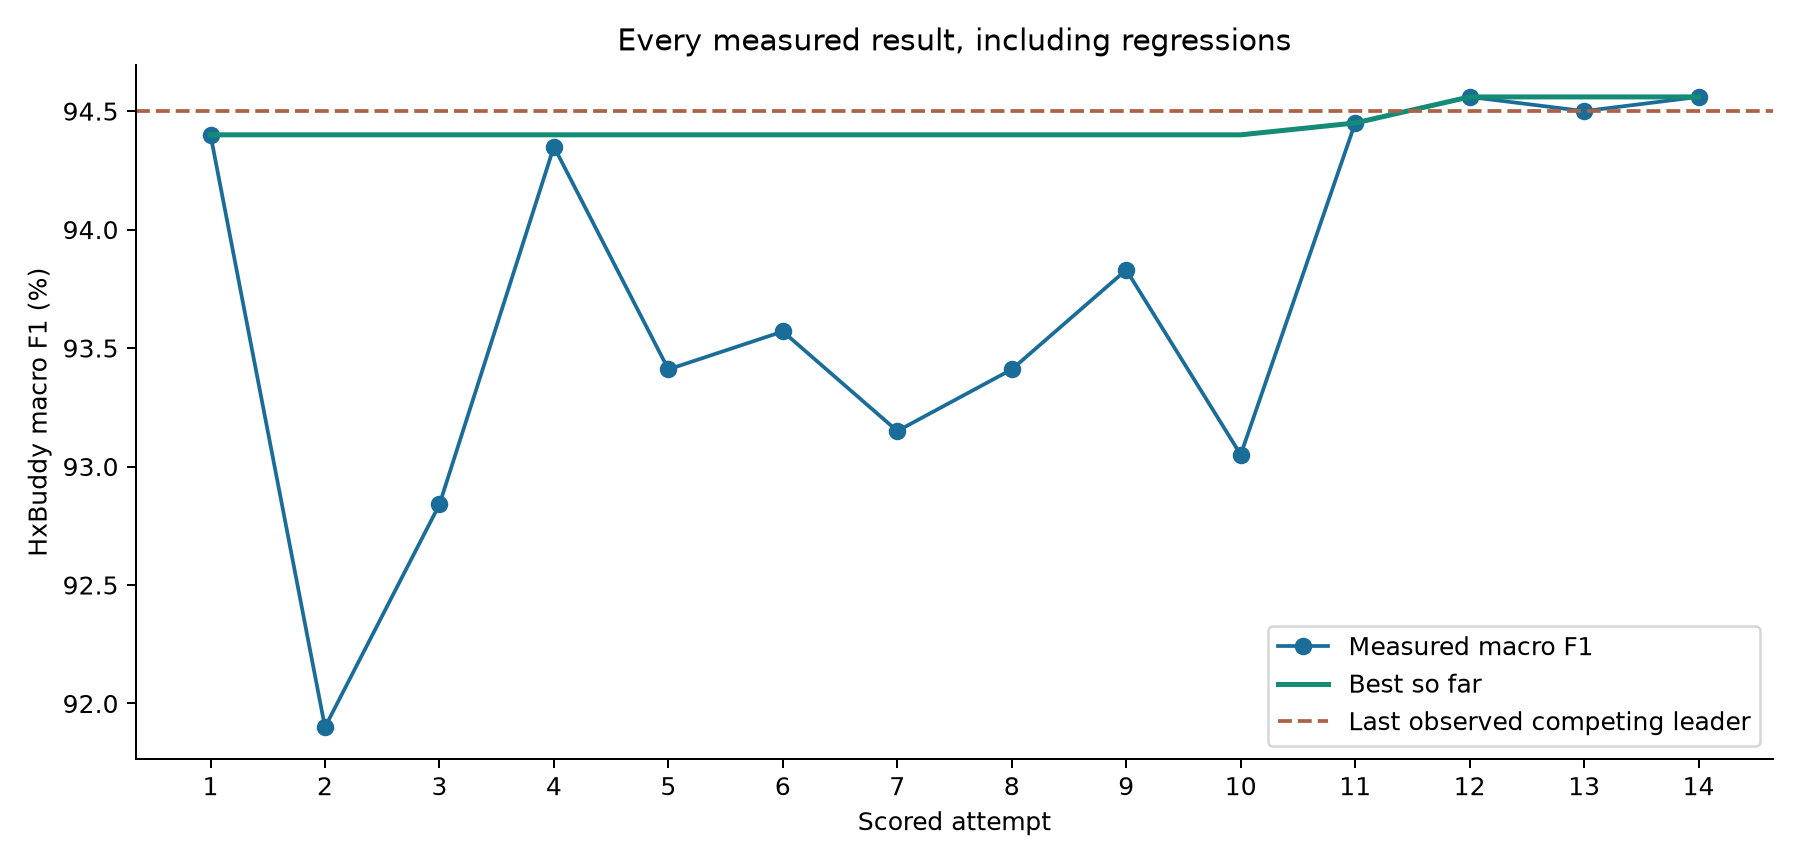

In [3]:
scores=pd.read_csv(root/'artifacts/scored_attempts.csv')
display(scores[['attempt','model','accuracy_percent','macro_f1_percent']])
display(Image(filename=str(root/'artifacts/score_progress.png')))

## Allocation and fairness

The champion selects 957 of 2,372 centre applicants (40.35%) and 643 of 1,628 remote applicants (39.50%). It changes 32 decisions from V1. The observed regional selection gap is 0.849 percentage points.

Our normative primary metric is equal opportunity under an independent, legitimate merit assessment. Its actual gap is unavailable. Demographic parity is an observable access diagnostic, not proof of fair treatment. Budget is a hard constraint. Small intersectional cells are marked rather than interpreted as precise disparities.

,region_administrative,n,v1_rate,champion_rate
0,Bas-Saint-Laurent,504,0.382937,0.371032
1,Capitale-Nationale,821,0.397077,0.405603
2,Cote-Nord,491,0.397149,0.395112
3,Gaspesie-Iles-de-la-Madeleine,633,0.415482,0.413902
4,Montreal,1551,0.401676,0.402321


,group,n,r_mean,work_mean,income_mean,remote_rate
0,new_grantees,16,28.570625,9.75,104179.8125,0.0625
1,displaced,16,28.695000,10.00,55349.2500,0.5625


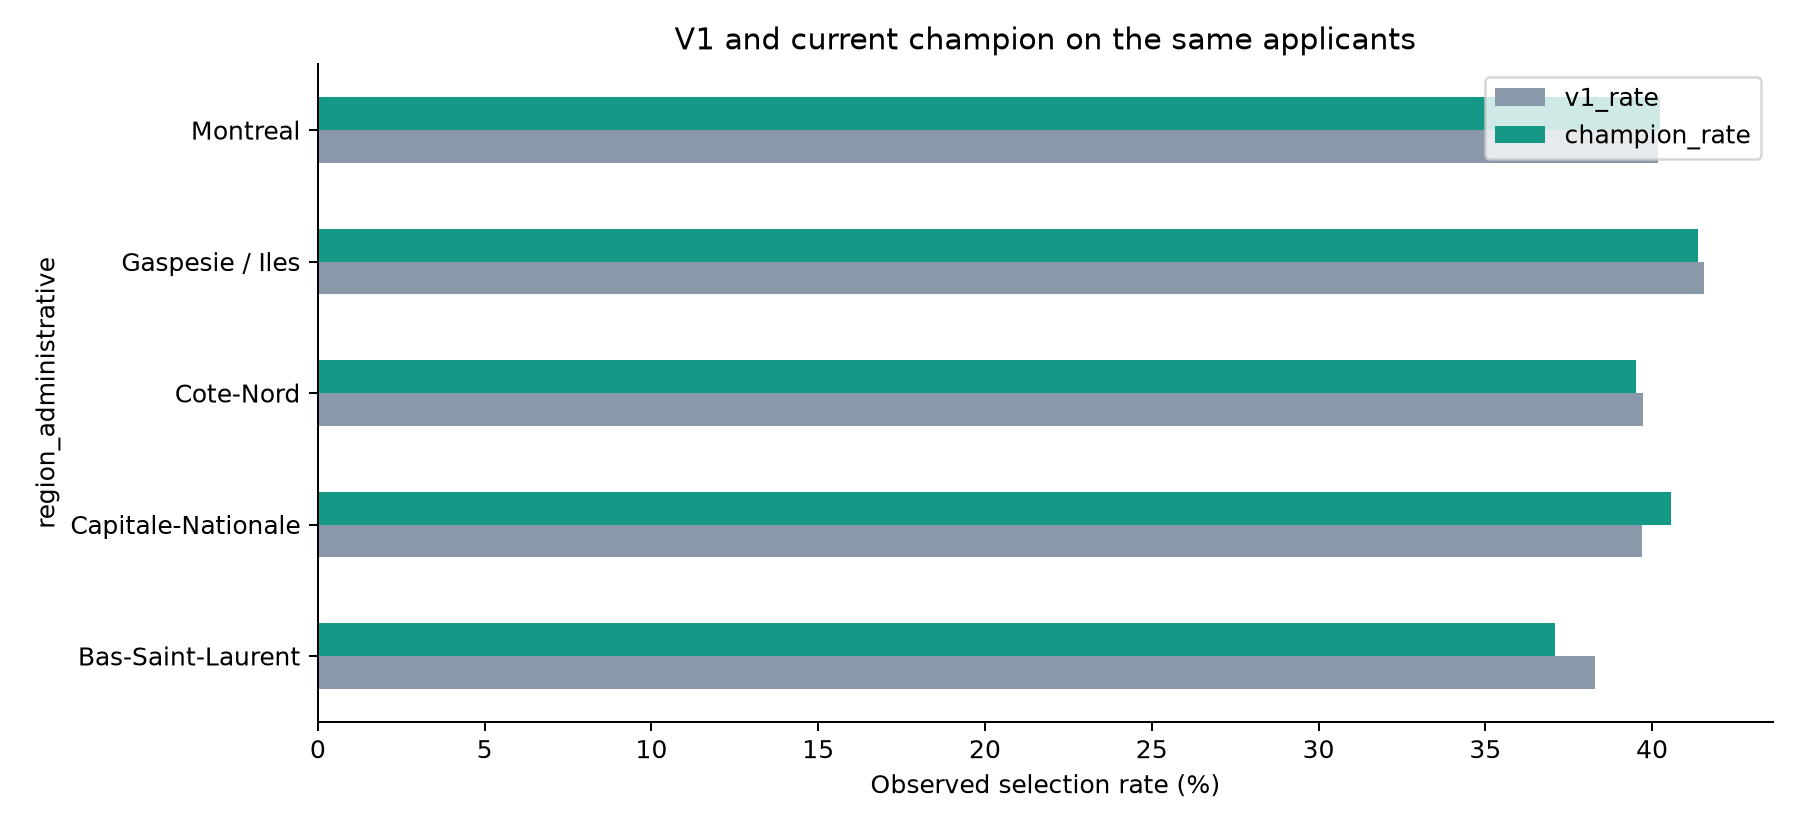

,region_administrative,premiere_generation_universitaire,programme_etudes,size,mean,small_cell
0,Bas-Saint-Laurent,0,Arts et lettres,54,0.407407,False
1,Bas-Saint-Laurent,0,Genie,60,0.383333,False
2,Bas-Saint-Laurent,0,Sante,47,0.297872,False
3,Bas-Saint-Laurent,0,Sciences,64,0.406250,False
4,Bas-Saint-Laurent,0,Sciences sociales,49,0.285714,False
5,Bas-Saint-Laurent,1,Arts et lettres,58,0.327586,False
6,Bas-Saint-Laurent,1,Genie,40,0.425000,False
7,Bas-Saint-Laurent,1,Sante,34,0.470588,False
8,Bas-Saint-Laurent,1,Sciences,43,0.441860,False
9,Bas-Saint-Laurent,1,Sciences sociales,55,0.309091,False


Small cells: 0


In [4]:
display(pd.read_csv(root/'artifacts/regional_rates.csv'))
display(pd.read_csv(root/'artifacts/decision_change_summary.csv'))
display(Image(filename=str(root/'artifacts/regional_access.png')))
intersections=pd.read_csv(root/'artifacts/intersection_audit.csv')
display(intersections)
print('Small cells:',int(intersections.small_cell.sum()))

## Opportunity / utility sensitivity

Ten tolerances constrain the true-positive-rate gap under the calibrated probability assumptions. Every point respects the same 40% budget. The plot is a Pareto sensitivity exercise, not a measured comparison of hidden-reference fairness or additional HxBuddy results. Cohort adaptation may make these probabilities optimistic. The independent equity component of the final rubric remains unknown.

,assumed_eop_tolerance,model_implied_eop_gap,model_implied_agreement,measured_dp_gap,grants,changed_from_champion
0,1.000,0.003931,0.946844,0.008494,1600,0
1,0.100,0.003931,0.946844,0.008494,1600,0
2,0.075,0.003931,0.946844,0.008494,1600,0
3,0.050,0.003931,0.946844,0.008494,1600,0
4,0.030,0.003931,0.946844,0.008494,1600,0
5,0.020,0.003931,0.946844,0.008494,1600,0
6,0.010,0.003931,0.946844,0.008494,1600,0
7,0.005,0.003931,0.946844,0.008494,1600,0
8,0.002,0.001302,0.946842,0.010566,1600,4
9,0.001,0.000012,0.946838,0.011601,1600,6


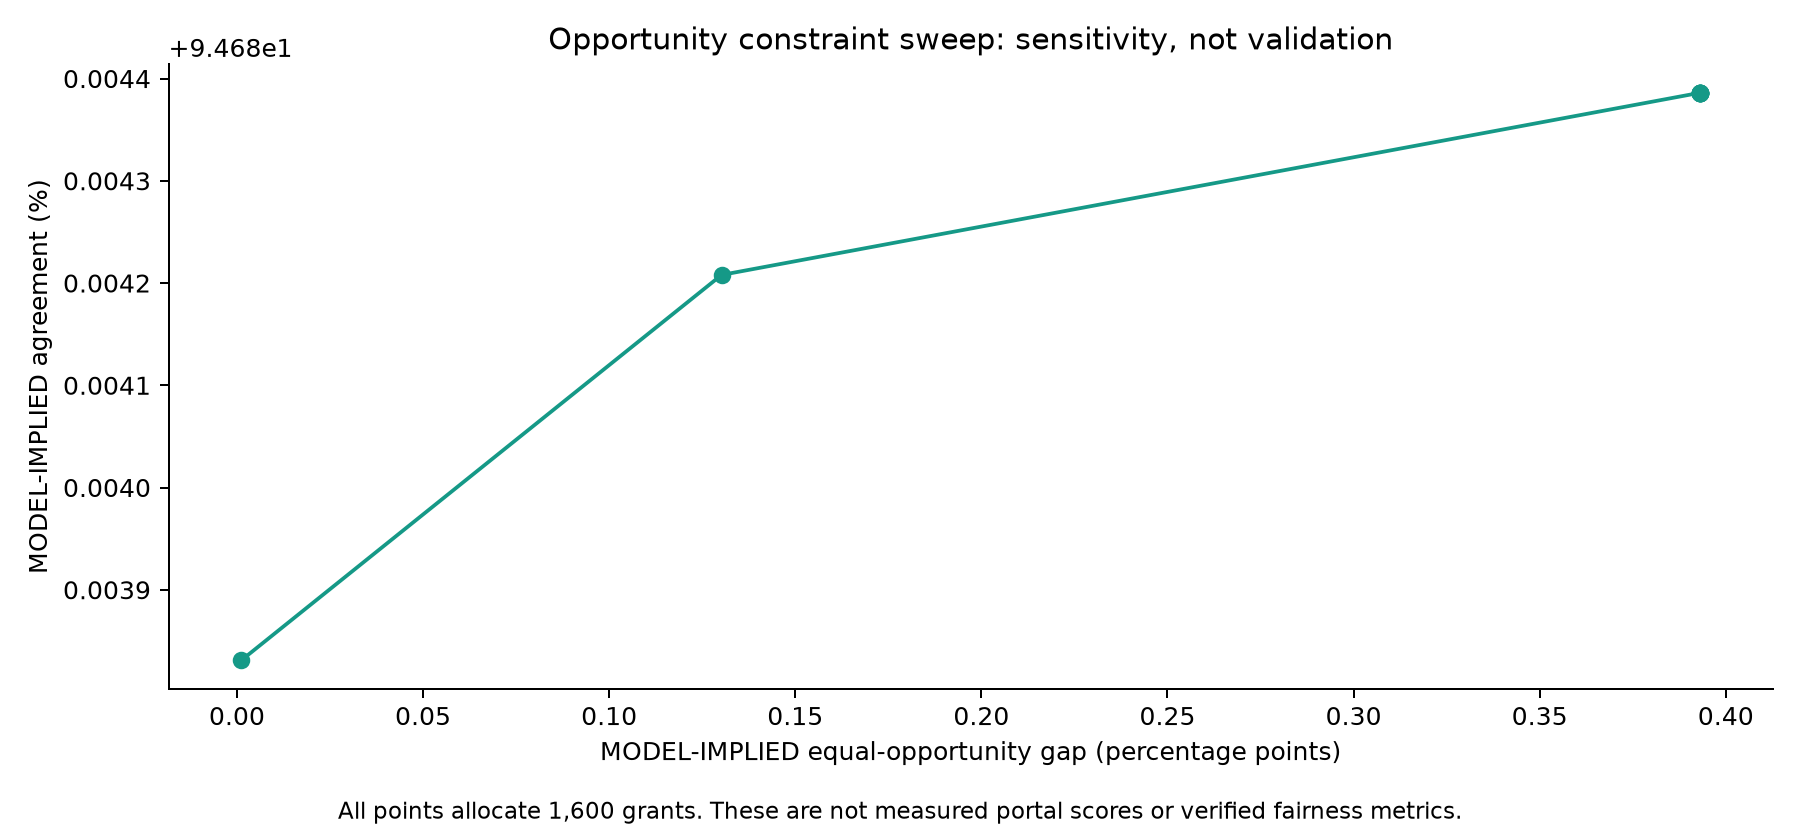

In [5]:
display(pd.read_csv(root/'artifacts/pareto.csv'))
display(Image(filename=str(root/'artifacts/pareto_front.png')))

## Governance and monitoring

An independent panel must define legitimate merit and review geographic and socioeconomic effects before real use. Validate on fresh applicants with independently adjudicated outcomes; measure opportunity, false-positive rates, selection rates and intersections with uncertainty. Keep an appeal and data-correction channel, review rejected applicants as well as recipients, and monitor distribution shift. Paid work must not penalize disability or caring obligations.

Freeze releases with data/code hashes, reject schema/budget violations, and keep rollback artifacts. The current model deliberately rejects new cohorts. No deployment is proposed from leaderboard feedback alone. `MONITORING.md` defines responsibilities and release conditions.

## Reproduce and sources

Run `python model_corrige.py`, `python -m unittest discover -s tests -v`, `python build_audit.py`, `python build_presentation.py`, then `python package_submission.py`. Required input is the unmodified IVADO participant package.

Sources: supplied IVADO briefs and baseline notebook; participant-reported first three scores; directly observed HxBuddy scores thereafter; [HxBuddy](https://hxbuddy.ca/); [Fairlearn metric definitions](https://fairlearn.org/main/user_guide/assessment/common_fairness_metrics.html). Python/SciPy/scikit-learn/ReportLab/Jupyter used. OpenAI Codex assisted implementation, analysis and writing. No pretrained predictor or external training dataset was used.